In [3]:
# If any import below fails, uncomment the line below, run it, then Restart Runtime:
# !pip install -q scikit-learn tensorflow opencv-python-headless

# ============================================================
# 🔧 Environment & Setup Check
# Run this first. It confirms every library works before we
# start building, and tells you if a GPU is available.
# ============================================================

import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

print("Python version:", sys.version.split()[0])
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

import sklearn
print("scikit-learn version:", sklearn.__version__)

import tensorflow as tf
print("TensorFlow version:", tf.__version__)

import cv2
print("OpenCV version:", cv2.__version__)

gpu_devices = tf.config.list_physical_devices("GPU")
if gpu_devices:
    print(f"\n✅ GPU available: {gpu_devices[0].name} — Project 2 will run faster.")
else:
    print("\nℹ️ No GPU detected — everything will still run, just a bit slower on Project 2.")
    print("   In Colab: Runtime → Change runtime type → Hardware accelerator → GPU")

print("\nAll core libraries imported successfully. You're ready to go! 🚀")

Python version: 3.11.9
NumPy version: 2.4.6
Pandas version: 3.0.5
scikit-learn version: 1.9.0
TensorFlow version: 2.21.0
OpenCV version: 5.0.0

ℹ️ No GPU detected — everything will still run, just a bit slower on Project 2.
   In Colab: Runtime → Change runtime type → Hardware accelerator → GPU

All core libraries imported successfully. You're ready to go! 🚀


In [4]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions
from tensorflow.keras.utils import load_img, img_to_array

print("TensorFlow version:", tf.__version__)

# Note: the first run downloads ~14 MB of pretrained weights.
# On shared classroom Wi-Fi with many students downloading at once,
# this can take a moment — that's expected, not an error.
image_model = MobileNetV2(weights="imagenet")
print("Pretrained MobileNetV2 loaded successfully.")

TensorFlow version: 2.21.0
14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 12s 1us/step
Pretrained MobileNetV2 loaded successfully.


ℹ️ Using sample image: sample_image.jpg (re-run this cell to upload your own)


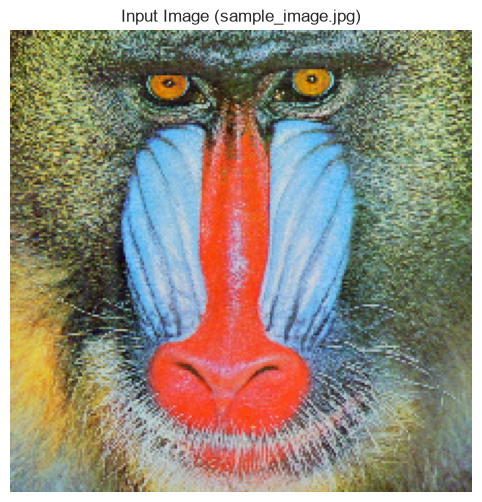

In [5]:
import os
import urllib.request

FALLBACK_IMAGE_URL = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/baboon.jpg"
FALLBACK_IMAGE_PATH = "sample_image.jpg"
image_path = None

# Option A: upload your own image (works in Google Colab)
try:
    from google.colab import files
    print("📤 Upload an image (jpg/png). Cancel/skip this dialog to use a sample image instead.")
    uploaded = files.upload()
    if uploaded:
        image_path = list(uploaded.keys())[0]
except ImportError:
    pass  # not running in Colab — fall through to the sample image

# Option B: guaranteed fallback so the demo always works
if not image_path:
    if not os.path.exists(FALLBACK_IMAGE_PATH):
        urllib.request.urlretrieve(FALLBACK_IMAGE_URL, FALLBACK_IMAGE_PATH)
    image_path = FALLBACK_IMAGE_PATH
    print(f"ℹ️ Using sample image: {image_path} (re-run this cell to upload your own)")

image = load_img(image_path, target_size=(224, 224))

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title(f"Input Image ({image_path})")
plt.show()

In [6]:
image_array = img_to_array(image)
image_batch = np.expand_dims(image_array, axis=0)
processed_image = preprocess_input(image_batch)

print("Original shape:", image_array.shape)
print("Batch shape:", image_batch.shape)

Original shape: (224, 224, 3)
Batch shape: (1, 224, 224, 3)


In [7]:
import time

start_time = time.time()
predictions = image_model.predict(processed_image, verbose=0)
elapsed_ms = (time.time() - start_time) * 1000

decoded_predictions = decode_predictions(
    predictions, top=5
)[0]

print(f"Prediction took {elapsed_ms:.1f} ms")
print("\nTop Predictions:")
for _, label, probability in decoded_predictions:
    print(f"{label}: {probability * 100:.2f}%")

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
Prediction took 2084.3 ms

Top Predictions:
baboon: 49.88%
vulture: 1.01%
jackfruit: 0.65%
wild_boar: 0.57%
ostrich: 0.56%
